In [3]:
import numpy as np 
from pathlib import Path

In [12]:
DATA_DIR = Path("../data/raw")
train_images_path = DATA_DIR/"train-images.idx3-ubyte"

In [13]:
print(train_images_path)

../data/raw/train-images.idx3-ubyte


In [14]:
print(train_images_path.exists())

True


In [16]:
print(Path.cwd())

/Users/goyalvai/projects/mnist-numpy/notebooks


In [18]:
print(train_images_path.stat().st_size)

47040016


In [19]:
with open(train_images_path, "rb") as f:
    header_bytes = f.read(16)

In [21]:
print(header_bytes)

b'\x00\x00\x08\x03\x00\x00\xea`\x00\x00\x00\x1c\x00\x00\x00\x1c'


In [23]:
print(len(header_bytes))

16


In [24]:
header = np.frombuffer(header_bytes, dtype=">u4")

In [26]:
magic, n_images, n_rows, n_cols = header
print(magic, n_images, n_rows, n_cols)

2051 60000 28 28


In [30]:
print(16 + n_images * n_rows * n_cols == train_images_path.stat().st_size)

True


In [31]:
with open(train_images_path, "rb") as f:
    f.seek(16)
    pixel_bytes = f.read()

train_images = np.frombuffer(pixel_bytes, dtype=np.uint8)

In [33]:
train_images = train_images.reshape(60000,28,28)

In [34]:
train_images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [35]:
print(train_images.shape)

(60000, 28, 28)


In [36]:
print(train_images.dtype)

uint8


In [37]:
print(train_images.min(), train_images.max())

0 255


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

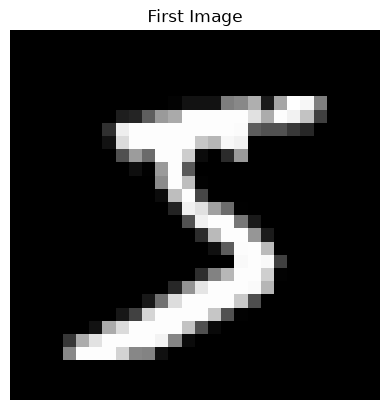

In [41]:
import matplotlib.pyplot as plt 
plt.imshow(train_images[0], cmap="gray") 
plt.title("First Image")
plt.axis("off")

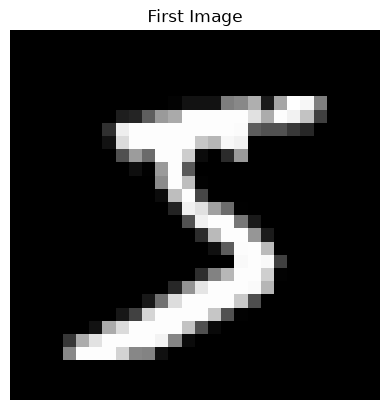

In [43]:
import matplotlib.pyplot as plt 
plt.imshow(train_images[0], cmap="gray") 
plt.title("First Image")
plt.axis("off")
plt.show()

In [44]:
train_images[0][10:15, 10:15]

array([[  1, 154, 253,  90,   0],
       [  0, 139, 253, 190,   2],
       [  0,  11, 190, 253,  70],
       [  0,   0,  35, 241, 225],
       [  0,   0,   0,  81, 240]], dtype=uint8)

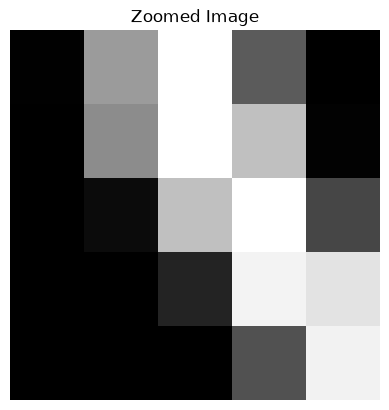

In [46]:
plt.imshow(train_images[0][10:15, 10:15], cmap="gray")
plt.title("Zoomed Image")
plt.axis("off")
plt.show()

In [51]:
train_labels_path = DATA_DIR/"train-labels.idx1-ubyte"

with open(train_labels_path, "rb") as f:
    label_magic, n_labels = np.frombuffer(f.read(8), dtype=">u4")
    train_labels = np.frombuffer(f.read(), dtype=np.uint8) 

print(label_magic, n_labels )
print(train_labels.shape)
print(train_labels[:10])

2049 60000
(60000,)
[5 0 4 1 9 2 1 3 1 4]


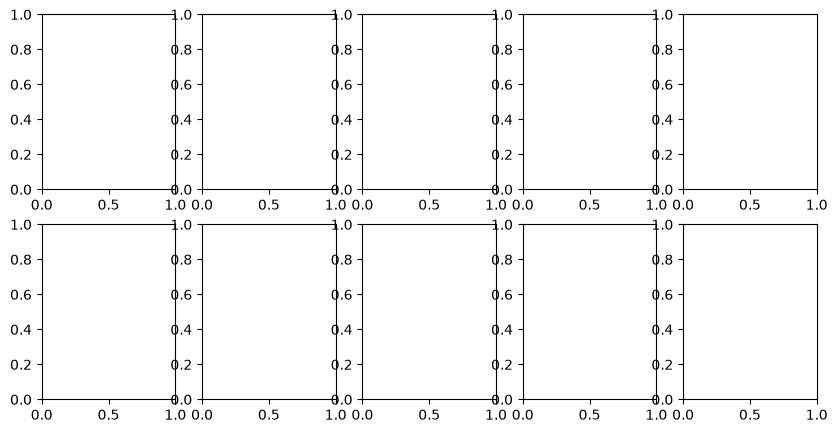

In [55]:
fig, axes = plt.subplots(2,5,figsize=(10,5))

In [59]:
axes.shape

(2, 5)

In [61]:
print(enumerate(axes.flat))

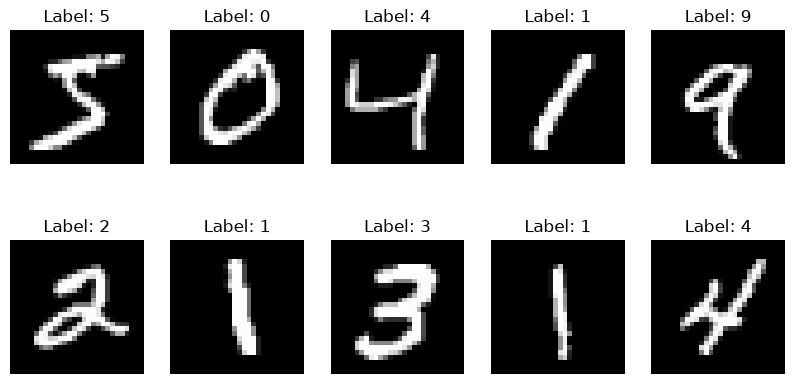

In [65]:
fig, axes = plt.subplots(2,5,figsize=(10,5))

for i,ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(f"Label: {train_labels[i]}") 
    ax.axis("off") 

plt.show()

In [66]:
digits, counts = np.unique(train_labels, return_counts=True)
digits, counts

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [73]:
print(tuple(zip(digits, counts)))
# as a metric, accuracy can be used here to see how well the model performed

((np.uint8(0), np.int64(5923)), (np.uint8(1), np.int64(6742)), (np.uint8(2), np.int64(5958)), (np.uint8(3), np.int64(6131)), (np.uint8(4), np.int64(5842)), (np.uint8(5), np.int64(5421)), (np.uint8(6), np.int64(5918)), (np.uint8(7), np.int64(6265)), (np.uint8(8), np.int64(5851)), (np.uint8(9), np.int64(5949)))


In [74]:
import sys 
sys.path.insert(0, str(Path.cwd().parent)) 

from src.data_loader import load_mnist

(train_images, train_labels), (test_images, test_labels) = load_mnist()

print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [75]:
print(train_labels[:10])

[5 0 4 1 9 2 1 3 1 4]
